In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

In [ ]:
df_1 = pd.read_excel(r"vendor1.xlsx")
df_2 = pd.read_excel(r"vendor2.xlsx")
df_1.info(), df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  35 non-null     int64  
 1   YS           35 non-null     float64
 2   Mpa          35 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 972.0 bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  48 non-null     int64  
 1   YS           48 non-null     float64
 2   Mpa          48 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


(None, None)

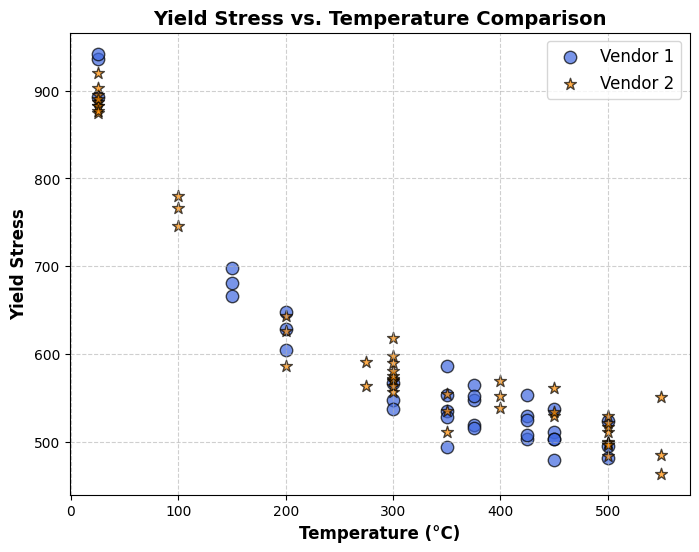

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(df_1["Temperature"], df_1["Mpa"], color='royalblue', edgecolors='black', alpha=0.7, s=80, label="Vendor 1")
plt.scatter(df_2["Temperature"], df_2["Mpa"], marker='*', color='darkorange', edgecolors='black', alpha=0.7, s=80, label="Vendor 2")

plt.xlabel("Temperature (°C)", fontsize=12, fontweight='bold')
plt.ylabel("Yield Stress", fontsize=12, fontweight='bold')
plt.title("Yield Stress vs. Temperature Comparison", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(fontsize=12)

plt.show()

In [4]:
data = pd.concat([df_1, df_2], ignore_index=True)
data_sorted = data.sort_values(by="Temperature", ascending=True)
df_3 = data_sorted.reset_index(drop=True)
df_3.head(10)

,Temperature,YS,Mpa
0,25,1.04164,935.996871
1,25,1.04832,941.999386
2,25,0.99379,892.999818
3,25,0.97376,875.001261
4,25,0.98711,886.997304
5,25,0.98155,882.001199
6,25,0.99602,895.003652
7,25,0.99045,889.998561
8,25,1.00492,903.001014
9,25,1.02384,920.002147


In [5]:
df_dict = {temp: df_3[df_3["Temperature"] == temp].reset_index(drop=True) for temp in df_3["Temperature"].unique()}

df_dict[550]

,Temperature,YS,Mpa
0,550,0.61319,551.000270
1,550,0.51637,463.999755
2,550,0.53974,484.999569


In [6]:
# Arrhenius Transform
data_sorted['Inverse_Temp'] = 11604.53 / (data_sorted['Temperature'] + 273.16)  # Convert to Kelvin
data_sorted['Ln_Mpa'] = np.log(data_sorted['Mpa'])  # Log transformation

In [7]:
# Sample data (Replace with actual values)
X = data_sorted['Inverse_Temp'].values  # Predictor variable
Y = data_sorted['Ln_Mpa'].values  # Response variable

# Compute means
X_mean = sum(X) / len(X)
Y_mean = sum(Y) / len(Y)

# Compute slope
numerator = sum((X[i] - X_mean) * (Y[i] - Y_mean) for i in range(len(X)))
denominator = sum((X[i] - X_mean) ** 2 for i in range(len(X)))
m = numerator / denominator

# Compute intercept
k = Y_mean - m * X_mean

# Display results
print(f"Intercept (k): {k:.5f}")
print(f"Slope (m): {m:.5f}")

Intercept (k): 5.85984
Slope (m): 0.02416


In [8]:
X = sm.add_constant(data_sorted['Inverse_Temp'])  # Predictor Variable (Inverse Temperature)
Y = data_sorted['Ln_Mpa']  # Response Variable (Log of Mpa)

# Fit Weibull Regression Model using MLE
model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Ln_Mpa   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     2020.
Date:                Mon, 07 Jul 2025   Prob (F-statistic):           4.89e-59
Time:                        16:54:17   Log-Likelihood:                 152.26
No. Observations:                  83   AIC:                            -300.5
Df Residuals:                      81   BIC:                            -295.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.8598      0.013    467.293   

In [9]:
from scipy import stats, optimize
# Log of observed values
Y_values = np.log(df_3['Mpa'].values)

# Define Lognormal Log-Likelihood Function (Normal distribution on log values)
def lognormal_log_likelihood(params, y):
    mu, sigma = params
    if sigma <= 0:
        return np.inf  # Avoid invalid sigma
    log_likelihood = np.sum(stats.norm.logpdf(y, loc=mu, scale=np.sqrt(sigma)))
    return -log_likelihood  # Minimize negative log-likelihood

# Initial guess: mean and std of log-data (or other guesses)
init_params = [10, 11]

# Optimize
bounds = [(None, None), (1e-10, None)]  # mu unbounded, sigma > 0
result_lognormal = optimize.minimize(
    lognormal_log_likelihood,
    init_params,
    args=(Y_values,),
    method='L-BFGS-B',
    bounds=bounds
)

# Extract estimated parameters
mu_est, sigma_est = result_lognormal.x
print(f"Estimated Lognormal μ: {mu_est:.4f}, σ (shape parameter s): {sigma_est:.4f}")

# For use with scipy.stats.lognorm:
# shape = sigma_est
# scale = np.exp(mu_est)

Estimated Lognormal μ: 6.3894, σ (shape parameter s): 0.0387


In [10]:
k = model.params.iloc[0]
sigma = sigma_est
m = model.params.iloc[1]

print(f"Intercept (k): {k:.4f}")
print(f"lognormal Shape Parameter (sigma): {sigma:.4f}")
print(f"Inverse Temperature Coefficient (m): {m:.4f}")

Intercept (k): 5.8598
lognormal Shape Parameter (sigma): 0.0387
Inverse Temperature Coefficient (m): 0.0242


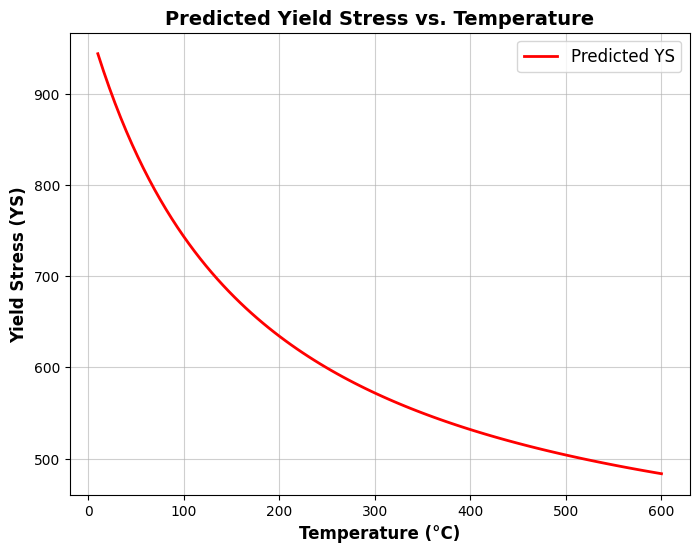

In [11]:
from scipy.special import erfinv  # Inverse error function

temperature_values = np.linspace(10, 600, 100)

# Fixed CDF value for prediction
cdf_values = 0.5 

# Compute predicted YS values using inverse error function (erfinv)
ys_predicted = np.exp(
    (k + (m * 11604.53) / (temperature_values + 273.16) + (np.sqrt(2) * sigma * erfinv(2 * cdf_values - 1)))
)

plt.figure(figsize=(8, 6))
plt.plot(temperature_values, ys_predicted, color="red", linestyle="-", linewidth=2, label="Predicted YS")

plt.xlabel("Temperature (°C)", fontsize=12, fontweight="bold")
plt.ylabel("Yield Stress (YS)", fontsize=12, fontweight="bold")
plt.title("Predicted Yield Stress vs. Temperature", fontsize=14, fontweight="bold")

plt.grid(True, linestyle="-", alpha=0.6)
plt.legend(fontsize=12)

plt.show()

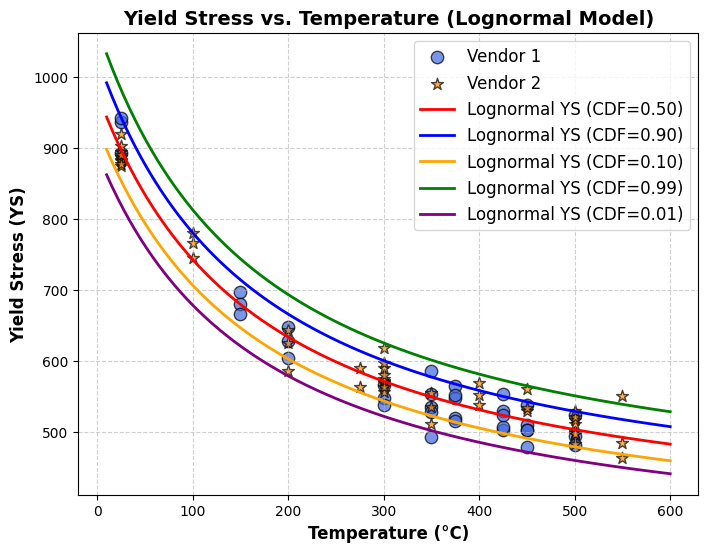

In [12]:
from scipy.special import erfinv
import numpy as np
import matplotlib.pyplot as plt

# Temperature range
temperature_values = np.linspace(10, 600, 100)

# CDF levels
cdf_50 = 0.5
cdf_90 = 0.9
cdf_10 = 0.1
cdf_99 = 0.99
cdf_01 = 0.01

# Lognormal-based YS predictions using erfinv-based quantile formula
def lognormal_prediction(cdf):
    z = np.sqrt(2) * sigma * erfinv(2 * cdf - 1)
    return np.exp(k + (m * 11604.53) / (temperature_values + 273.16) + z)

ys_predicted_cdf_50 = lognormal_prediction(cdf_50)
ys_predicted_cdf_90 = lognormal_prediction(cdf_90)
ys_predicted_cdf_10 = lognormal_prediction(cdf_10)
ys_predicted_cdf_99 = lognormal_prediction(cdf_99)
ys_predicted_cdf_01 = lognormal_prediction(cdf_01)

# Plotting
plt.figure(figsize=(8, 6))

# Scatter plots (keep if vendor data is available)
plt.scatter(df_1["Temperature"], df_1["Mpa"], color='royalblue', edgecolors='black', alpha=0.7, s=80, label="Vendor 1")
plt.scatter(df_2["Temperature"], df_2["Mpa"], marker='*', color='darkorange', edgecolors='black', alpha=0.7, s=80, label="Vendor 2")

# Predicted curves
plt.plot(temperature_values, ys_predicted_cdf_50, color="red", linewidth=2, label="Lognormal YS (CDF=0.50)")
plt.plot(temperature_values, ys_predicted_cdf_90, color="blue", linewidth=2, label="Lognormal YS (CDF=0.90)")
plt.plot(temperature_values, ys_predicted_cdf_10, color="orange", linewidth=2, label="Lognormal YS (CDF=0.10)")
plt.plot(temperature_values, ys_predicted_cdf_99, color="green", linewidth=2, label="Lognormal YS (CDF=0.99)")
plt.plot(temperature_values, ys_predicted_cdf_01, color="purple", linewidth=2, label="Lognormal YS (CDF=0.01)")

plt.xlabel("Temperature (°C)", fontsize=12, fontweight="bold")
plt.ylabel("Yield Stress (YS)", fontsize=12, fontweight="bold")
plt.title("Yield Stress vs. Temperature (Lognormal Model)", fontsize=14, fontweight="bold")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

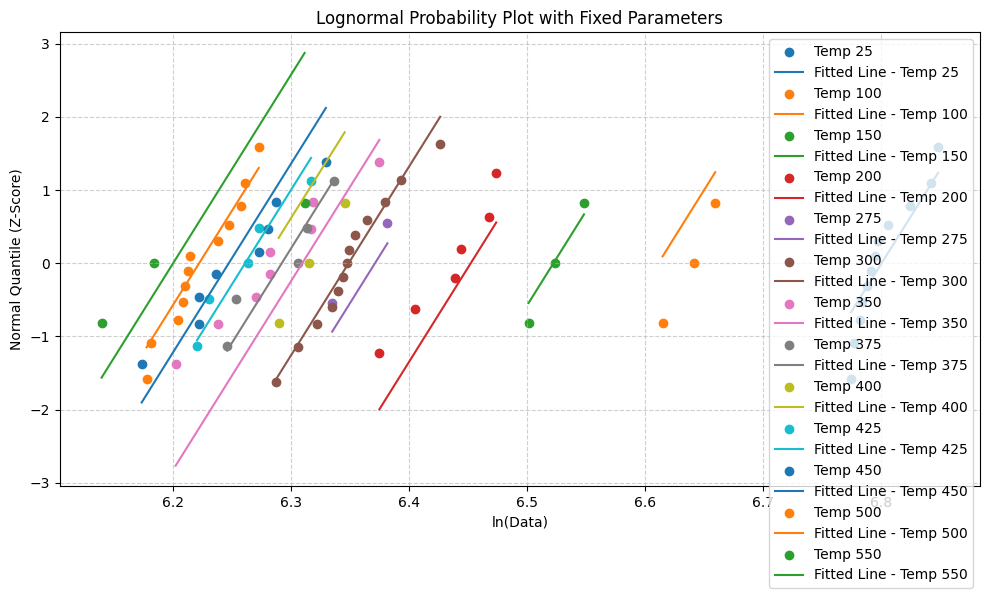

In [13]:
def median_rank(n, i):
    return (i - 0.3) / (n + 0.4)

plt.figure(figsize=(10, 6))

for temp in df_dict.keys():
    data = df_dict[temp]["Mpa"].values
    data = np.sort(data)

    n = len(data)
    p_values = np.array([median_rank(n, i + 1) for i in range(n)])

    # Lognormal probability transformation
    x_values = np.log(data)
    y_values = stats.norm.ppf(p_values)

    # Scatter plot of actual data
    plt.scatter(x_values, y_values, label=f"Temp {temp}")

    # Use regression-derived parameters
    k_fixed = k
    m_fixed = m
    sigma_fixed = sigma
    inverse_temp = 11604.53 / (temp + 273.16)

    mu = k_fixed + m_fixed * inverse_temp  # location of lognormal
    median = np.exp(mu)

    # Fit line using fixed μ and σ
    x_fit = np.linspace(min(data), max(data), 100)
    y_fit = stats.norm.ppf(stats.lognorm.cdf(x_fit, s=sigma_fixed, scale=median))
    plt.plot(np.log(x_fit), y_fit, linestyle='-', label=f"Fitted Line - Temp {temp}")

plt.title("Lognormal Probability Plot with Fixed Parameters")
plt.xlabel("ln(Data)")
plt.ylabel("Normal Quantile (Z-Score)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()